***Notebook to predict the likelihood of a Nigerian univeristy students to drop out.***

***

**1. Importing Libraries and loading Data**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')





In [2]:
# Load the dataset

df = pd.read_csv('../data/students.csv')
df.head()

,Student_ID,Age,Gender,State_of_origin,School_location,Distance_from_home_km,Jamb_score,O_level_credits,Current_cgpa,Cgpa_trend,...,Fee_payment_status,Has_scholarship,Works_part_time,Family_income_bracket,Parent_education_level,Failed_courses_count,Asuu_strike_semesters,Mental_health_support,Course_load,Dropout
0,STU0001,29,Female,Lagos,Rural,369,265,3,3.77,Declining,...,Paid,1,0,Middle,Tetiarary,3,2,1,20,0
1,STU0002,22,Female,Enugu,Urban,94,250,5,3.11,Stable,...,Partial,0,0,High,No formal,0,0,0,22,0
2,STU0003,22,Male,Kano,Rural,724,201,3,2.26,Declining,...,Owing,0,1,High,Tetiarary,2,1,0,24,0
3,STU0004,30,Female,Kano,Rural,168,283,3,3.79,Stable,...,Partial,0,0,High,Primary,1,3,1,24,0
4,STU0005,21,Male,Edo,Urban,485,267,5,3.41,Stable,...,Partial,0,1,Low,Secondary,1,2,0,13,0


In [3]:
# View dataset information
df.shape
df.dtypes
df.info()
df.describe()
# Check for missing values
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 2546 entries, 0 to 2545
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              2546 non-null   str    
 1   Age                     2546 non-null   int64  
 2   Gender                  2546 non-null   str    
 3   State_of_origin         2546 non-null   str    
 4   School_location         2546 non-null   str    
 5   Distance_from_home_km   2546 non-null   int64  
 6   Jamb_score              2546 non-null   int64  
 7   O_level_credits         2546 non-null   int64  
 8   Current_cgpa            2546 non-null   float64
 9   Cgpa_trend              2546 non-null   str    
 10  Attendance_rate         2546 non-null   float64
 11  Fee_payment_status      2546 non-null   str    
 12  Has_scholarship         2546 non-null   int64  
 13  Works_part_time         2546 non-null   int64  
 14  Family_income_bracket   2546 non-null   str    
 15

Student_ID                0
Age                       0
Gender                    0
State_of_origin           0
School_location           0
Distance_from_home_km     0
Jamb_score                0
O_level_credits           0
Current_cgpa              0
Cgpa_trend                0
Attendance_rate           0
Fee_payment_status        0
Has_scholarship           0
Works_part_time           0
Family_income_bracket     0
Parent_education_level    0
Failed_courses_count      0
Asuu_strike_semesters     0
Mental_health_support     0
Course_load               0
Dropout                   0
dtype: int64

**2. Exploratory Data Analysis**

*Percentage of students that drop out*

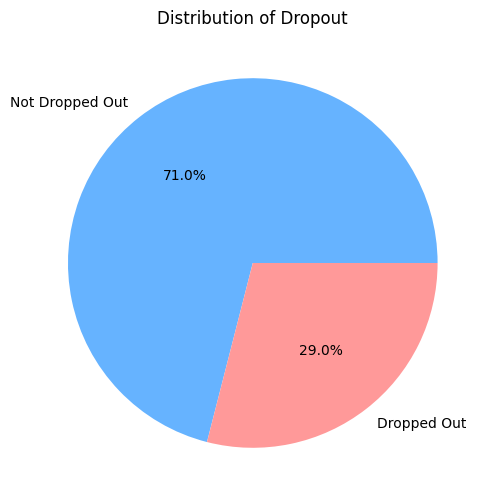

In [4]:
# Pie chart of dropout distribution
plt.figure(figsize=(6,6))
plt.pie(df['Dropout'].value_counts(), labels=['Not Dropped Out', 'Dropped Out'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Dropout')
plt.show()

This chart shows the ratio of students that dropped out of universities and those that didn't.


*Distribution of dropouts with rresect to fee_payment_status* 

Text(0, 0.5, 'Dropout Rate')

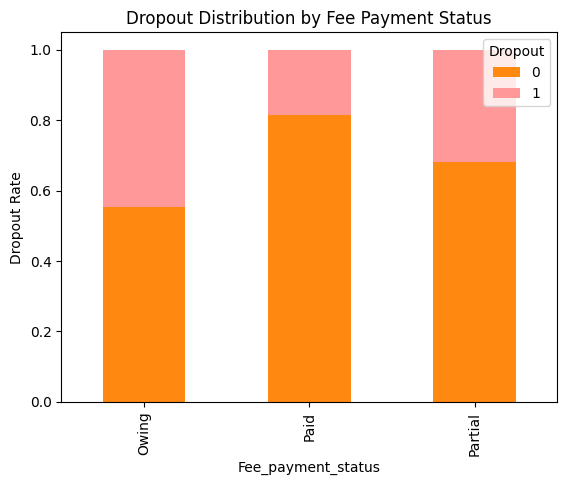

In [5]:
# Dropout distribution by Fee payment status
dropout_by_fee = df.groupby('Fee_payment_status')['Dropout'].value_counts(normalize=True).unstack()
dropout_by_fee.plot(kind='bar', stacked=True, color=['#ff8811','#ff9999'])
plt.title('Dropout Distribution by Fee Payment Status') 
plt.ylabel('Dropout Rate')

This Chart shows the correlation between Fee payment status and how many people in each category Dropout(1) or Stay(0). It shows that those owing school fees are the most likely to dropout.

*Distribution of dropout bases on CGPA*

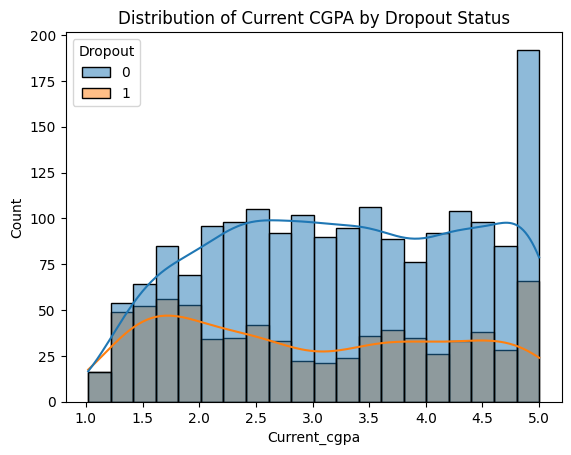

In [6]:
sns.histplot(data=df, x='Current_cgpa', bins=20, color='#66b3ff', hue='Dropout', kde=True)
plt.title('Distribution of Current CGPA by Dropout Status') 
plt.ylabel('Count')
plt.show()

This histogram shows the distribution of dropout rates based on current CGPA. We see that more dropouts are present at the lower CGPA ranges than at the lower CGPA ranges



*Dropout Rate by ASUU Strike semesters*

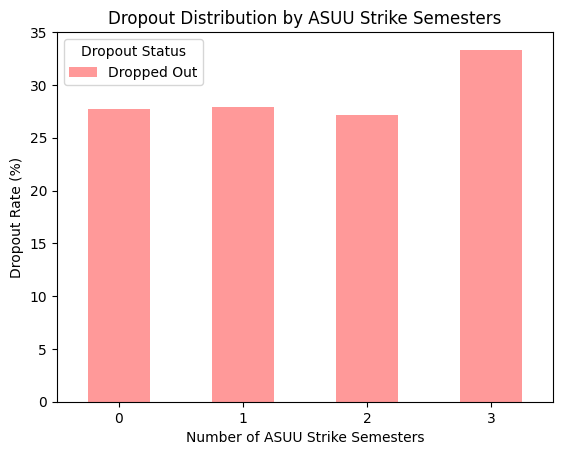

In [7]:
asuu_dropout = df.groupby('Asuu_strike_semesters')['Dropout'].mean() * 100
asuu_dropout.plot(kind='bar', color='#ff9999')
plt.title('Dropout Distribution by ASUU Strike Semesters')
plt.xlabel('Number of ASUU Strike Semesters')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Dropout Status', labels=['Dropped Out'])
plt.show()

This chart shows the percentage chance of dropping out of University based on number semesteers affected by ASUU strikes. We see that There is a relatively level chance from semesters 0-2 but a spike from semester 3.

*Dropout rate by family income bracket*

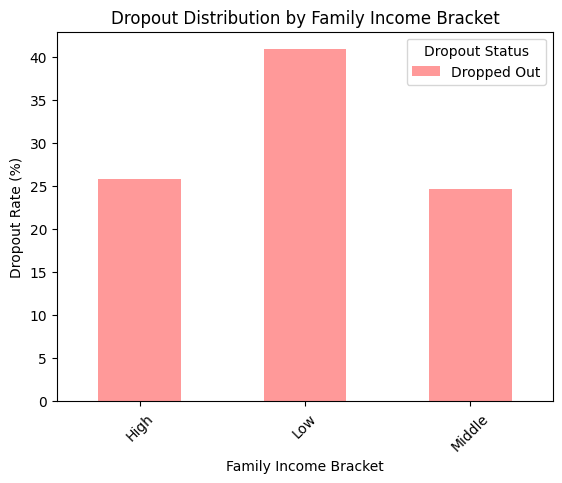

In [8]:
families_dropout = df.groupby('Family_income_bracket')['Dropout'].mean() * 100
families_dropout.plot(kind='bar', color='#ff9999')
plt.title('Dropout Distribution by Family Income Bracket')  
plt.xlabel('Family Income Bracket')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Dropout Status', labels=['Dropped Out'])

This chart shows the rate at which Students' family income level affects dropout likelihood. It shows that Low income households tend to have hgher rates of dropouts, while middle or high income families have relatively equal chances of dropping out.


*Correlation heatmap*

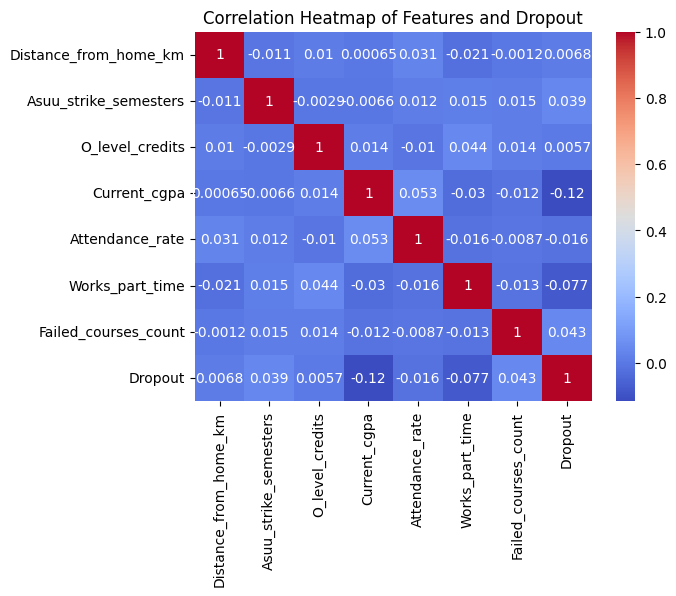

In [9]:
features = ['Distance_from_home_km', 'Asuu_strike_semesters', 'O_level_credits', 'Current_cgpa', 'Attendance_rate', 'Works_part_time', 'Failed_courses_count']
X = df[features]
y = df['Dropout']
sns.heatmap(df[features + ['Dropout']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features and Dropout')
plt.show()


This heatmap shows that there is little to no correlations with these set of columns.

***3.Preprocessing***

In [10]:
#Drop Student_ID column
df.drop(columns="Student_ID", inplace=True)

# labelencoding
cat_cols = [
    "Gender", "State_of_origin", "School_location",
    "Cgpa_trend", "Fee_payment_status",
    "Family_income_bracket", "Parent_education_level"
]

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and targets
X = df.drop(columns="Dropout")
y= df["Dropout"].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y)



In [11]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

In [12]:
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


***4. Model training and comparison***

In [13]:
# Models being used
models = {
"Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        use_label_encoder=False, eval_metric="logloss", random_state=42
    )
}



In [14]:
# Model comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name,model in models.items():
    cvscore = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring="roc_auc")
    results[name] = cvscore
    print(f"{name:25s} | ROC_AUC: {cvscore.mean():.4f} +- {cvscore.std():.4f}")
    

Logistic Regression       | ROC_AUC: 0.7762 +- 0.0102
Decision Tree             | ROC_AUC: 0.7479 +- 0.0222
Random Forest             | ROC_AUC: 0.8603 +- 0.0133
XGBoost                   | ROC_AUC: 0.8418 +- 0.0189


**MODEL RESULTS**
| Model | ROC-AUC Mean | Std |
|---|---|---|
| Logistic Regression | 0.7762 | 0.0102 |
| Decision Tree | 0.7479 | 0.0222 |
| Random Forest | 0.8603 | 0.0133 |
| XGBoost | 0.8418 | 0.0189 |

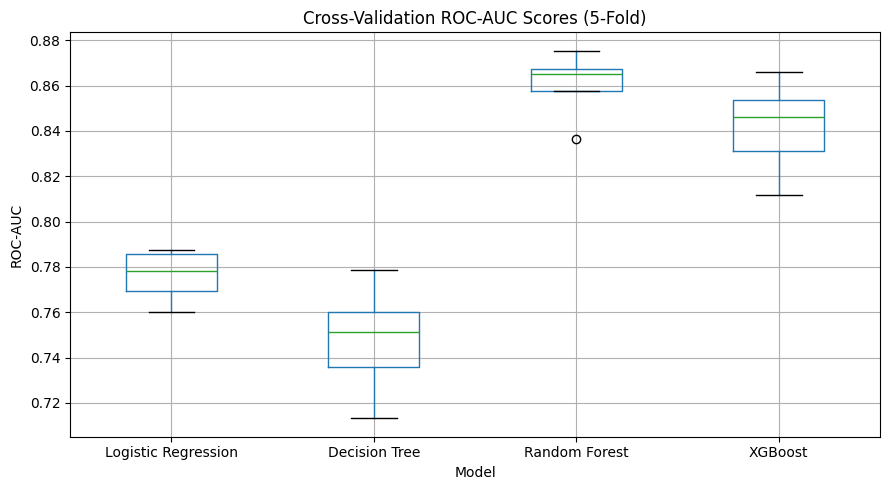

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
cv_df = pd.DataFrame(results)
cv_df.boxplot(ax=ax)
ax.set_title("Cross-Validation ROC-AUC Scores (5-Fold)")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("Model")
plt.tight_layout()
plt.savefig("../reports/cv_comparison.png")
plt.show()


**6. Model evaluation (Best Model= RandomForestClassifier)**

In [22]:
best_model = models["Random Forest"]
best_model.fit(X_train_res,y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# Training the best model with test data
y_pred = best_model.predict(X_train_res)
y_prob = best_model.predict_proba(X_test)[:,1]